# ML Unsupervised Algorithms

### Group Work + Homework
#### Unsupervised learnign on IRIS data

- for iris dataset (hint: do no tforget to preprocess the data):
    - reduce the dimensions to 2 using PCA
    - plot resulting two principal components in a scatter plot and use target labels from iris data to color individual classes
    - analyze how much information (variance) can be attributed to each of the principal components (hint: use the attribute explained_variance_ratio_)
    - use the elbow method to select the optimal number of clusters
    - perform k-mean clustering with various initiation {‘k-means++’}
    - plot results of kmeans
    - use the target variable to estimate the clustering precision


In [ ]:
from sklearn.datasets import load_iris
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

from sklearn.metrics import silhouette_score
from sklearn.metrics import accuracy_score
from scipy.stats import mode

# in case that you want to use pca package to show PCA properties
from pca import pca

# in case you want to use programatical way to estimate the number of cluster with elbow method
from kneed import KneeLocator
# or use this
from yellowbrick.cluster import KElbowVisualizer

In [ ]:
iris = load_iris()
df= pd.DataFrame(data= np.c_[iris['data'], iris['target']],columns= list(iris['feature_names']) + ['target'])
df['target_names'] = iris.target_names[df['target'].astype(int)]
df


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_names
0,5.1,3.5,1.4,0.2,0.0,setosa
1,4.9,3.0,1.4,0.2,0.0,setosa
2,4.7,3.2,1.3,0.2,0.0,setosa
3,4.6,3.1,1.5,0.2,0.0,setosa
4,5.0,3.6,1.4,0.2,0.0,setosa
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2.0,virginica
146,6.3,2.5,5.0,1.9,2.0,virginica
147,6.5,3.0,5.2,2.0,2.0,virginica
148,6.2,3.4,5.4,2.3,2.0,virginica


In [3]:
# your code

# Separating out the features
x = df.loc[:, list(iris['feature_names']) ].values
y = df.loc[:,['target']].values

# Standardizing the features
X = StandardScaler().fit_transform(x)

In [ ]:
# PCA projection to lower dimensional space (number of dimensions depends on n-components parameter)
pcamodel = PCA(n_components=2)
principalComponents = pcamodel.fit_transform(X)
principalDf = pd.DataFrame(data = principalComponents, columns = ['pc1', 'pc2'])
finalDf = pd.concat([principalDf, df['target'], df['target_names']], axis = 1)


(150, 2)


<Axes: xlabel='pc1', ylabel='pc2'>

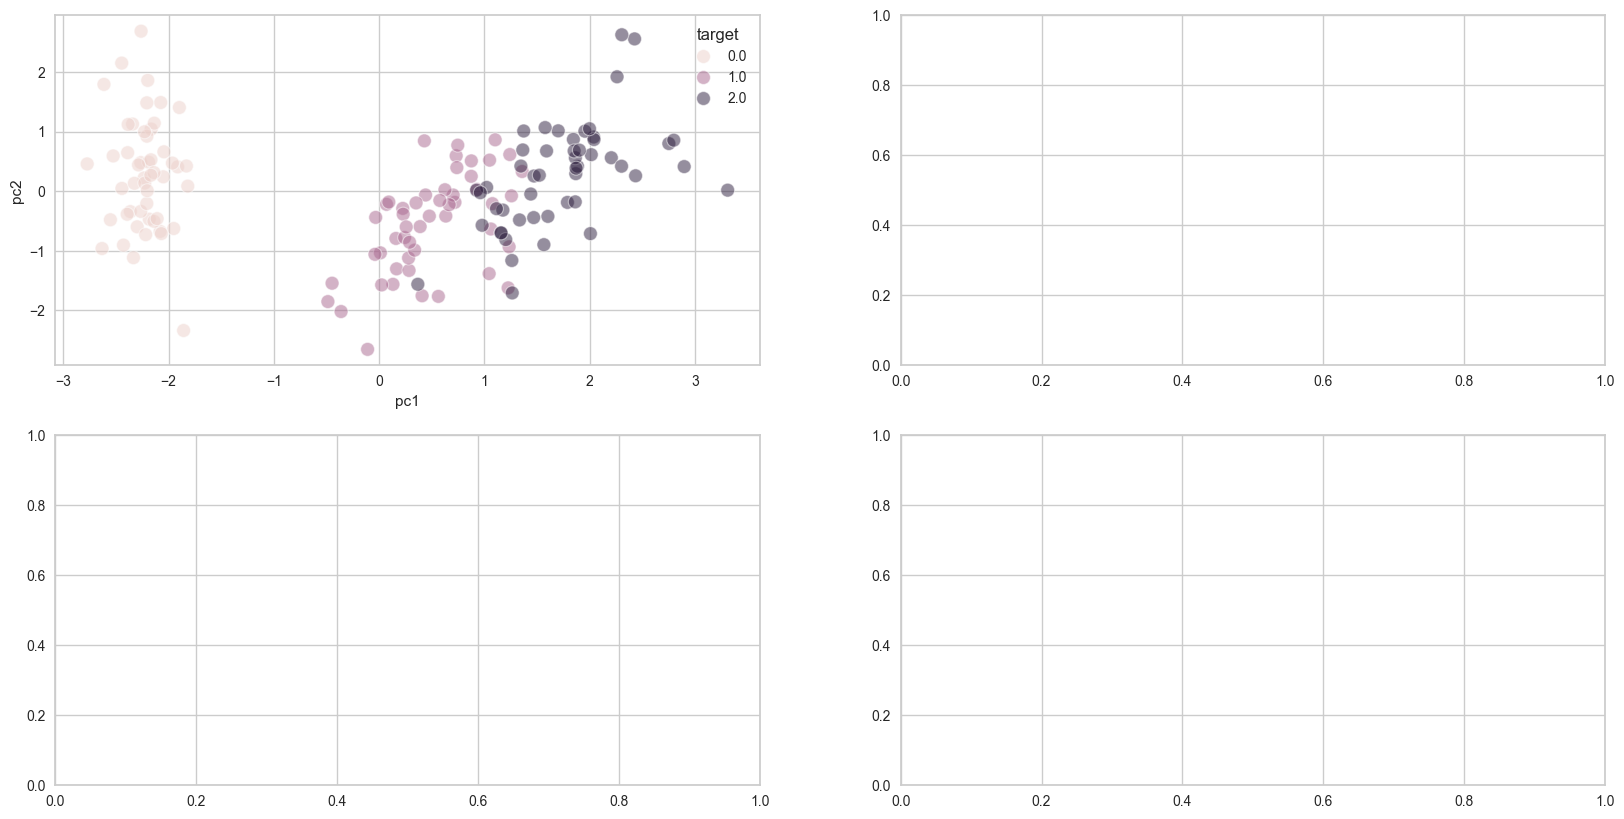

In [8]:
# to define the pallete for graphs
# many different palletes can be chosen https://seaborn.pydata.org/tutorial/color_palettes.html
# sns.set_palette('Paired')
sns.set_palette('Set1') # change the parameter (pallete name) to get different graph appearance

#highest representations:
fig, axs = plt.subplots(2,2, figsize=(20, 10))
sns.scatterplot(x= 'pc1', y='pc2', hue='target', data=finalDf, ax=axs[0,0], alpha=0.5, s=100)

In [10]:
print("low variance ratio")
print((pcamodel.explained_variance_ratio_), sum(pcamodel.explained_variance_ratio_))
print(pcamodel.components_.shape) # has shape [n_components, n_features]


print("PC retain 90% variance:")
print((pcamodel2.explained_variance_ratio_), sum(pcamodel2.explained_variance_ratio_)) # 24 PC retain 90% of the variance of original dataset
print(pcamodel2.components_.shape) # has shape [n_components, n_features]


low variance ratio
[0.72962445 0.22850762] 0.9581320720000166
(2, 4)
PC retain 90% variance:
[0.72962445 0.22850762] 0.9581320720000166
(2, 4)


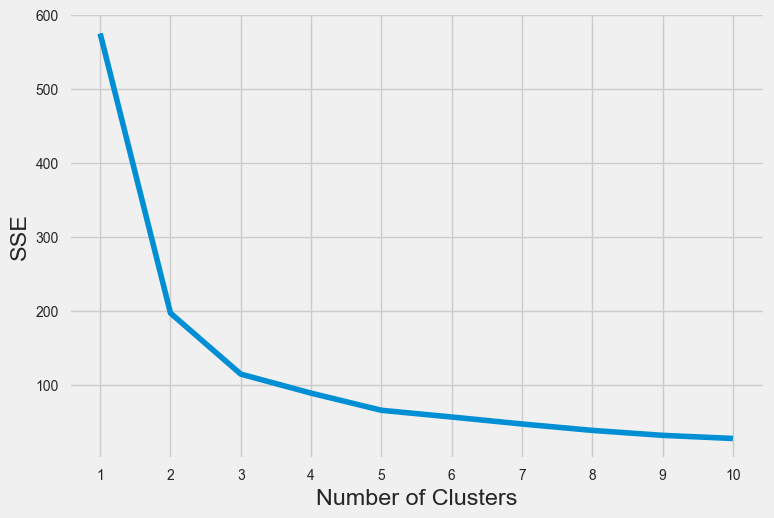

In [11]:
# determining b=number of cluster by elbow method
kmeans_kwargs = {
  "init": 'k-means++',
  "n_init": 20,
  "max_iter": 100,
  "random_state": 10,
}

# A list holds the SSE values for each k
sse = []
for k in range(1, 11):
  kmeans = KMeans(n_clusters=k, **kmeans_kwargs)
  kmeans.fit(principalDf)
  sse.append(kmeans.inertia_)
plt.style.use("fivethirtyeight")
plt.plot(range(1, 11), sse)
plt.xticks(range(1, 11))
plt.xlabel("Number of Clusters")
plt.ylabel("SSE")
plt.show()
# we can visually see that the curve has break point at either 2 or 3 cllusters

In [12]:
# an automatic way to select nmebr of clusters based on computed SSE
from kneed import KneeLocator
kl = KneeLocator(range(1, 11), sse, curve="convex", direction="decreasing")
print('We will select {} clusters'.format(kl.elbow))

We will select 3 clusters


In [30]:
# perform kmeans clustering fro different init methods
methods = ['k-means++', 'random']

number_clusters = kl.elbow

kmeans = []
for method in methods:
  kmeans_kwargs = {
    "init": method,
    "n_init": 20,
    "max_iter": 100,
    "random_state": 42,
  }
  kmeans.append(KMeans(n_clusters=number_clusters, **kmeans_kwargs))

In [35]:
# fit models with both init methods
clusters_random_method = kmeans[1].fit_predict(principalDf) # Compute cluster centers and predict cluster index for each sample
clusters_kmeans_method = kmeans[0].fit_predict(principalDf) # Compute cluster centers and predict cluster index for each sample

<Axes: xlabel='pc1', ylabel='pc2'>

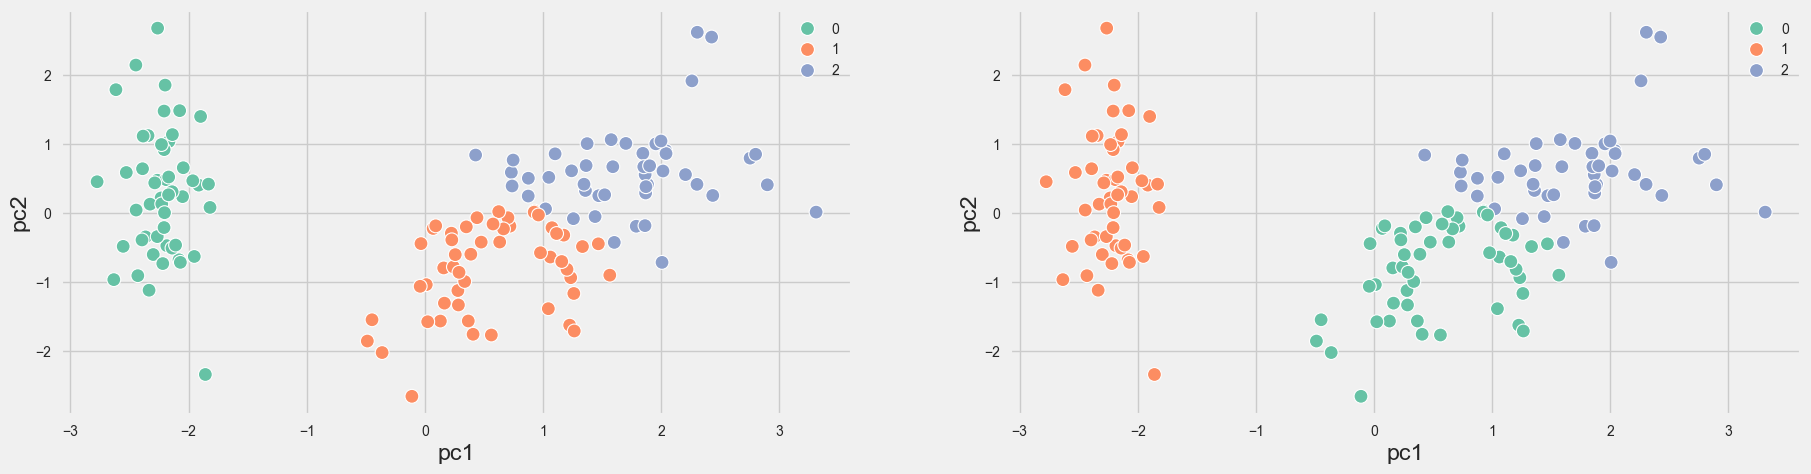

In [36]:
# plot results of kmeans
fig, axs = plt.subplots(1, 2, figsize = (20, 5))

sns.scatterplot(x = 'pc1', y ='pc2', hue = clusters_random_method, data=principalDf, ax = axs[0], s=100, palette="Set2")

sns.scatterplot(x = 'pc1', y ='pc2', hue = clusters_kmeans_method, data=principalDf, ax = axs[1], s=100, palette="Set2")

# results look similar or the same, but the cluster label is different per init method

In [37]:
targets = df['target'].values.astype(int)

def get_clusterlabels(clusters, number_clusters):
  labels = np.zeros_like(clusters)
  for i in range(number_clusters):
      mask = (clusters == i) # for each digit we mask the data and focus only on one digit per one loop
      # print(*targets[mask])
      # print(*mask)
      # print(*targets[mask].shape)
      # print(*mask.shape)
      labels[mask] = mode(targets[mask])[0] # I am assgning the most common value to the variable labels at the index positions defined by mask
      print('cluster number', i, ', most common valus in the cluster', *[mode(targets[mask])[0]])
  return labels

In [40]:
# get proper labels for random initialization
labels_random = get_clusterlabels(clusters_random_method, number_clusters)
# get proper labels for kmeans initialization
labels_kmeans = get_clusterlabels(clusters_kmeans_method, number_clusters)


cluster number 0 , most common valus in the cluster 0
cluster number 1 , most common valus in the cluster 1
cluster number 2 , most common valus in the cluster 2
cluster number 0 , most common valus in the cluster 1
cluster number 1 , most common valus in the cluster 0
cluster number 2 , most common valus in the cluster 2


<Axes: xlabel='pc1', ylabel='pc2'>

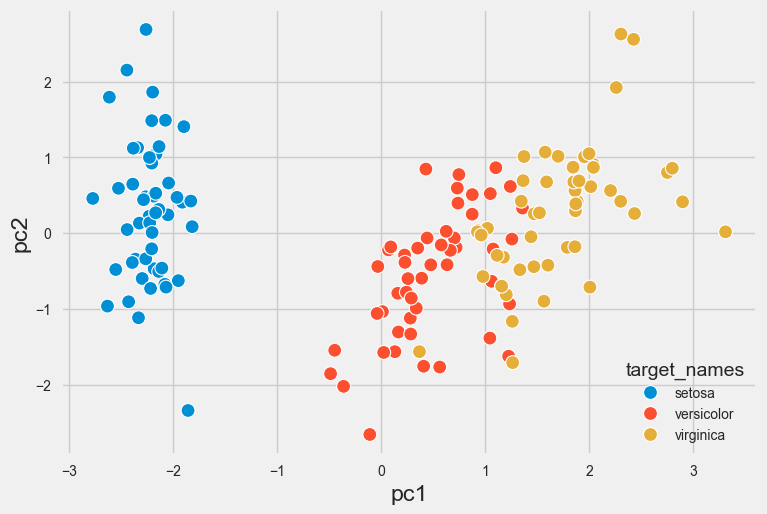

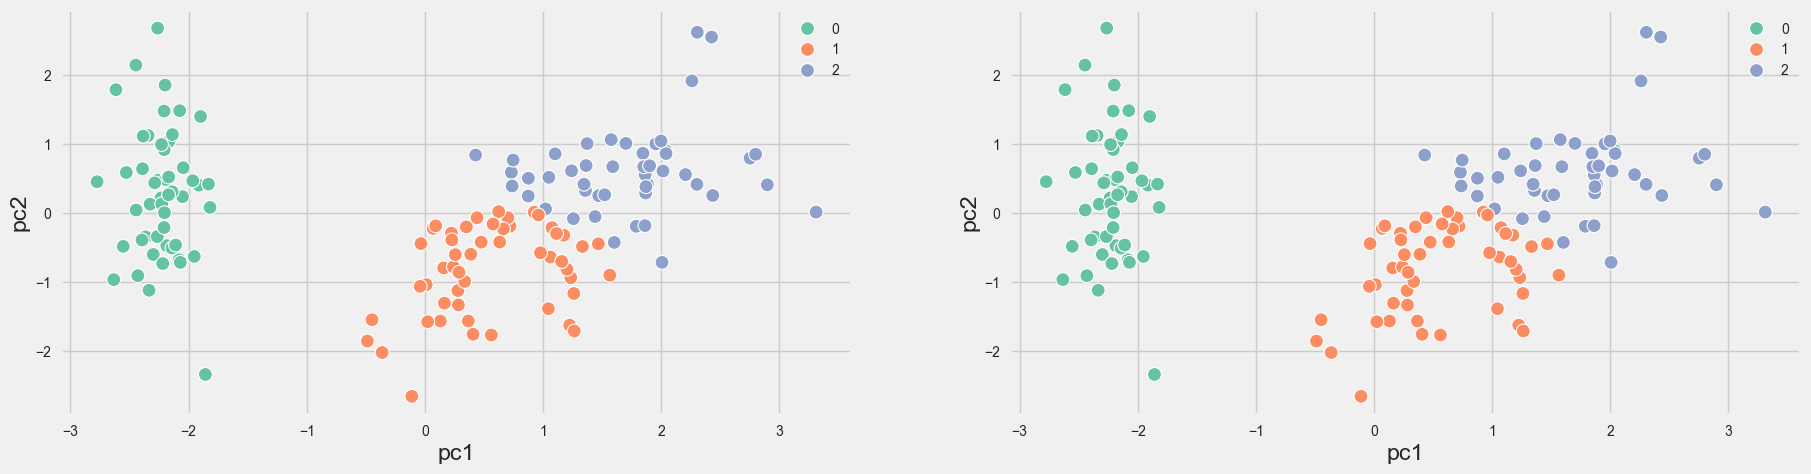

In [42]:
# plot results of kmeans with correct labels
sns.scatterplot(x= 'pc1', y='pc2', hue='target_names', data=finalDf, s=100)

fig, axs = plt.subplots(1, 2, figsize = (20, 5))

sns.scatterplot(x = 'pc1', y ='pc2', hue = labels_random, data=principalDf, ax = axs[0], s=100, palette="Set2")

sns.scatterplot(x = 'pc1', y ='pc2', hue = labels_kmeans, data=principalDf, ax = axs[1], s=100, palette="Set2")